In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns


from pathlib import Path

sns.set_theme(style="white", font_scale=0.9)

BASE_DIR = Path("../results")

BACKBONES = ["dinov2", "resnet18", "resnet50", "vgg16"]

MODALITIES = [
    "SAR-QXSLAB",
    "OPT-QXSLAB",
    "HE",
    "IHC",
    "CT",
    "T1",
    "T2",
    "SAR-SEN12",
    "OPT-SEN12",
    "ImageNet-1k",
]

SIZE_MIN, SIZE_MAX = 30, 220
CMAP = sns.color_palette("flare", as_cmap=True)

METRIC_INFO = {
    "gaussian_mmd": (
        "Gaussian MMD",
        "Mean Distance (sq. Eucl. \u2192 RBF)",
    ),
    "centroid_distance": (
        "Centroid Distance",
        "Euclidean Distance",
    ),
    "sinkhorn_cosine": (
        "Sinkhorn (Cosine Cost)",
        "Regularized OT cost (sq. cosine-distance ground cost)",
    ),
    "sinkhorn_euclidean": (
        "Sinkhorn (Sq. Euclidean Cost)",
        "Regularized OT cost (sq. Euclidean ground cost)",
    ),
    "mean_cost": (
        "Mean Cost (Euclidean)",
        "Mean Euclidean Cost",
    ),
}

METRICS = list(METRIC_INFO)
METRIC_TITLES = {k: v[0] for k, v in METRIC_INFO.items()}
METRIC_CBAR_LABEL = {k: v[1] for k, v in METRIC_INFO.items()}

PER_PLOT_NORM = {"centroid_distance", "sinkhorn_euclidean", "mean_cost"}

In [2]:
def load_matrix(backbone, metric, kind):
    path = BASE_DIR / backbone / f"{metric}_{kind}.csv"
    return (
        pd.read_csv(path, index_col=0)
        .loc[MODALITIES, MODALITIES]
        .astype(float)
        .to_numpy()
    )


def lower_triangle(arr):
    arr = arr.copy()
    arr[np.triu_indices_from(arr, k=0)] = np.nan
    return arr


def scale_sizes(std, std_min, std_max):
    if std_max == std_min:
        return np.full_like(std, (SIZE_MIN + SIZE_MAX) / 2)
    std = np.clip(std, std_min, std_max)
    return SIZE_MIN + (SIZE_MAX - SIZE_MIN) * (std - std_min) / (std_max - std_min)


def plot_dotplot(ax, mean, std, title, norm, std_min, std_max):
    n = len(MODALITIES)
    y, x = np.indices(mean.shape)
    valid = ~np.isnan(mean)

    sc = ax.scatter(
        x[valid],
        y[valid],
        c=mean[valid],
        s=scale_sizes(std[valid], std_min, std_max),
        cmap=CMAP,
        norm=norm,
        edgecolors="white",
        linewidths=0.5,
        alpha=0.95,
        zorder=3,
    )

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks(range(n), MODALITIES, rotation=90, fontsize=8)
    ax.set_yticks(range(n), MODALITIES, fontsize=8)

    for k in np.arange(n + 1) - 0.5:
        ax.axhline(k, color="#e5e5e5", linewidth=0.6, zorder=1)
        ax.axvline(k, color="#e5e5e5", linewidth=0.6, zorder=1)

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.5, n - 0.5)
    ax.invert_yaxis()
    ax.tick_params(left=False, bottom=False)
    sns.despine(ax=ax, left=True, bottom=True)
    return sc


def _compute_norms(data, metric):
    per_plot = metric in PER_PLOT_NORM
    all_stds = np.concatenate([s[~np.isnan(s)] for _, s in data.values()])
    global_std_min, global_std_max = all_stds.min(), all_stds.max()

    if per_plot:
        norms = {
            bb: mcolors.Normalize(
                vmin=mean[~np.isnan(mean)].min(),
                vmax=mean[~np.isnan(mean)].max(),
            )
            for bb, (mean, _) in data.items()
        }
    else:
        all_means = np.concatenate([m[~np.isnan(m)] for m, _ in data.values()])
        global_norm = mcolors.Normalize(vmin=all_means.min(), vmax=all_means.max())
        norms = {bb: global_norm for bb in data}

    return per_plot, norms, global_std_min, global_std_max


def _add_colorbar(fig, axes, scs, norms, metric, per_plot):
    cbar_y, cbar_h = 0.20, 0.030
    if per_plot:
        for ax, sc in zip(axes, scs):
            pos = ax.get_position()
            cax = fig.add_axes([pos.x0, cbar_y, pos.width, cbar_h])
            cb = fig.colorbar(sc, cax=cax, orientation="horizontal")
            cb.ax.tick_params(labelsize=7)
            cb.set_label(METRIC_CBAR_LABEL[metric], fontsize=6)
    else:
        norm = list(norms.values())[0]
        sm = cm.ScalarMappable(norm=norm, cmap=CMAP)
        sm.set_array([])
        x0 = axes[0].get_position().x0
        x1 = axes[-1].get_position().x1
        cw = (x1 - x0) * 0.45
        cx = (x0 + x1) / 2 - cw / 2
        cax = fig.add_axes([cx, cbar_y, cw, cbar_h])
        cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
        cb.ax.tick_params(labelsize=8)
        cb.set_label(METRIC_CBAR_LABEL[metric], fontsize=9)


def _add_size_legend(fig, std_min, std_max):
    std_vals = np.array([std_min, (std_min + std_max) / 2, std_max])
    std_sizes = scale_sizes(std_vals, std_min, std_max)
    handles = [
        plt.scatter(
            [], [], s=s, c="#888888", alpha=0.85, edgecolors="white", linewidths=0.5
        )
        for s in std_sizes
    ]
    fig.legend(
        handles,
        [f"{v:.3f}" for v in std_vals],
        title="Std dev (dot size)",
        loc="lower right",
        bbox_to_anchor=(0.97, 0.01),
        ncol=3,
        fontsize=7,
        title_fontsize=8,
        framealpha=0.9,
        borderpad=0.8,
    )


def plot_metric(metric):
    data = {
        bb: (
            lower_triangle(load_matrix(bb, metric, "mean")),
            lower_triangle(load_matrix(bb, metric, "std")),
        )
        for bb in BACKBONES
    }

    per_plot, norms, global_std_min, global_std_max = _compute_norms(data, metric)

    fig, axes = plt.subplots(1, len(BACKBONES), figsize=(4.5 * len(BACKBONES), 8))
    fig.subplots_adjust(left=0.09, right=0.97, bottom=0.38, top=0.88, wspace=0.45)

    scs = []
    for ax, backbone in zip(axes, BACKBONES):
        mean, std = data[backbone]
        norm = norms[backbone]
        if per_plot:
            valid_stds = std[~np.isnan(std)]
            std_min, std_max = valid_stds.min(), valid_stds.max()
        else:
            std_min, std_max = global_std_min, global_std_max
        sc = plot_dotplot(ax, mean, std, backbone.upper(), norm, std_min, std_max)
        scs.append(sc)

    _add_colorbar(fig, axes, scs, norms, metric, per_plot)
    _add_size_legend(fig, global_std_min, global_std_max)
    fig.suptitle(METRIC_TITLES[metric], fontsize=13, fontweight="bold")
    return fig

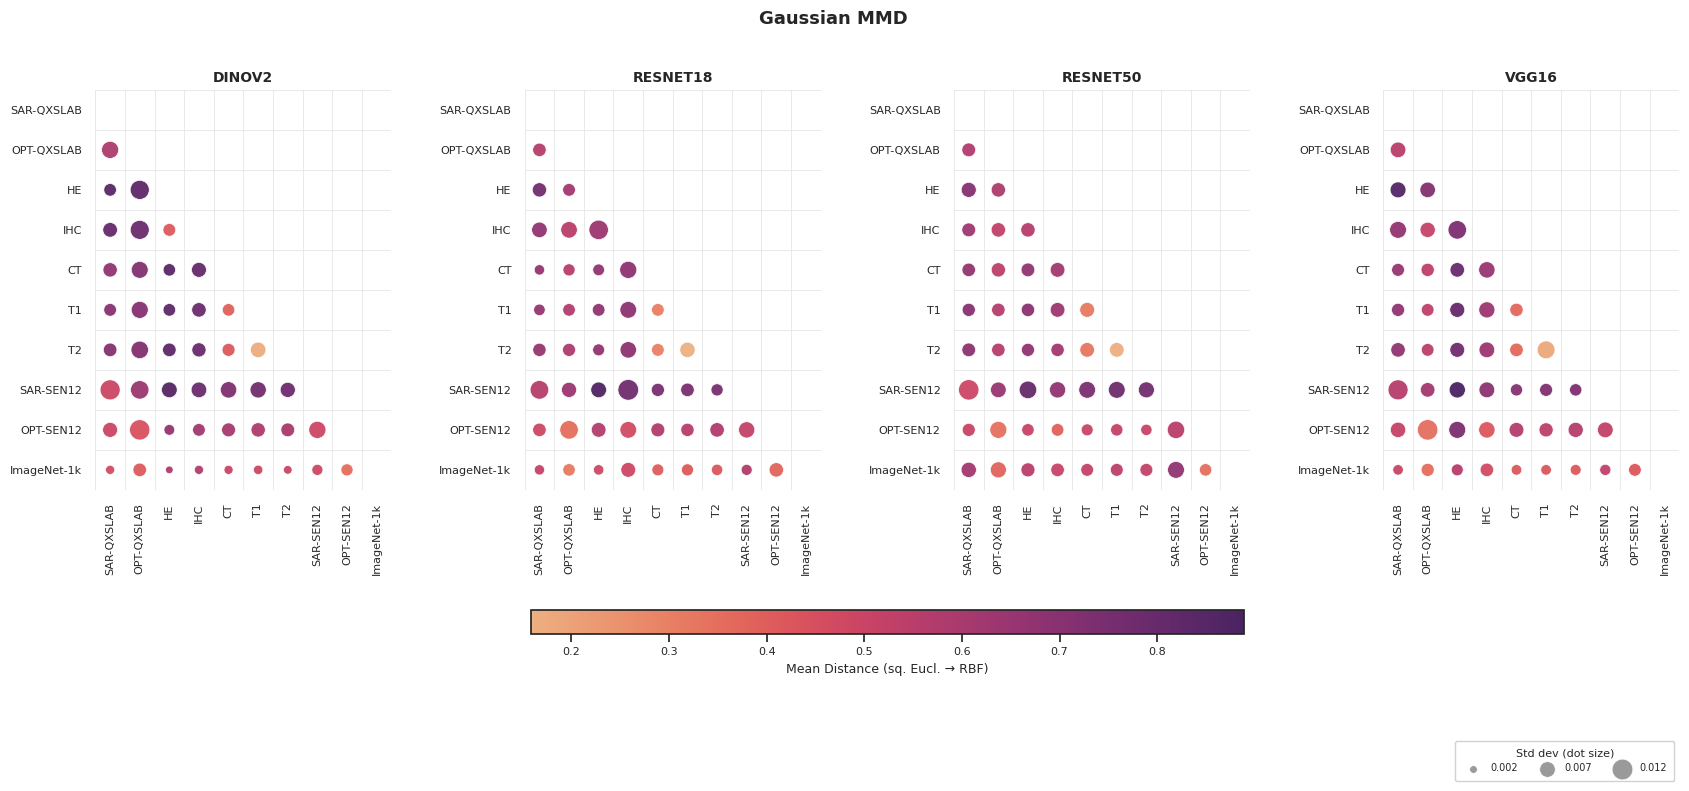

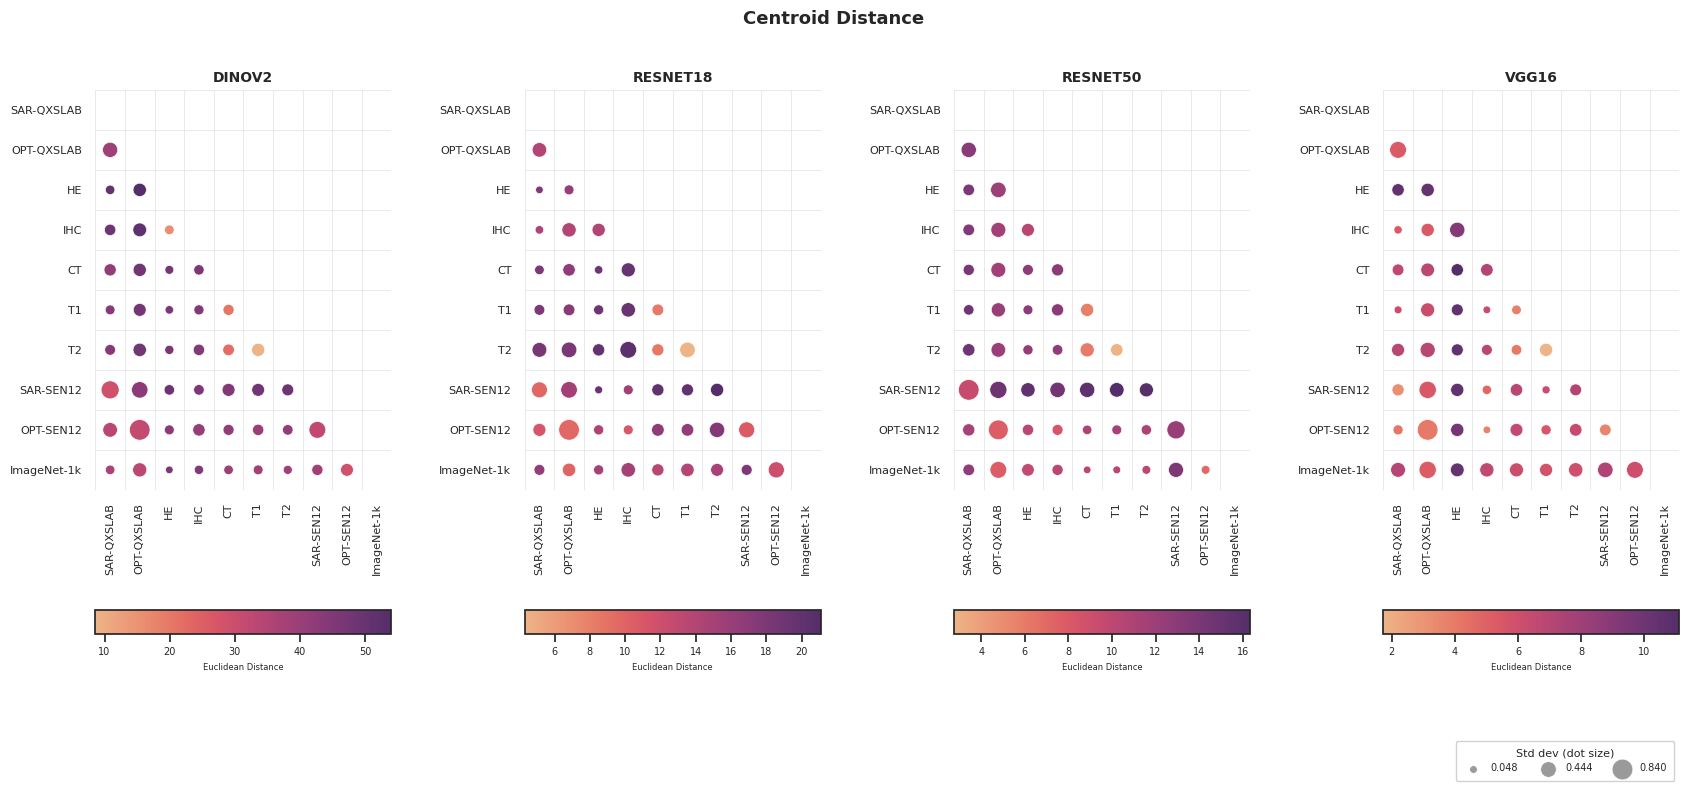

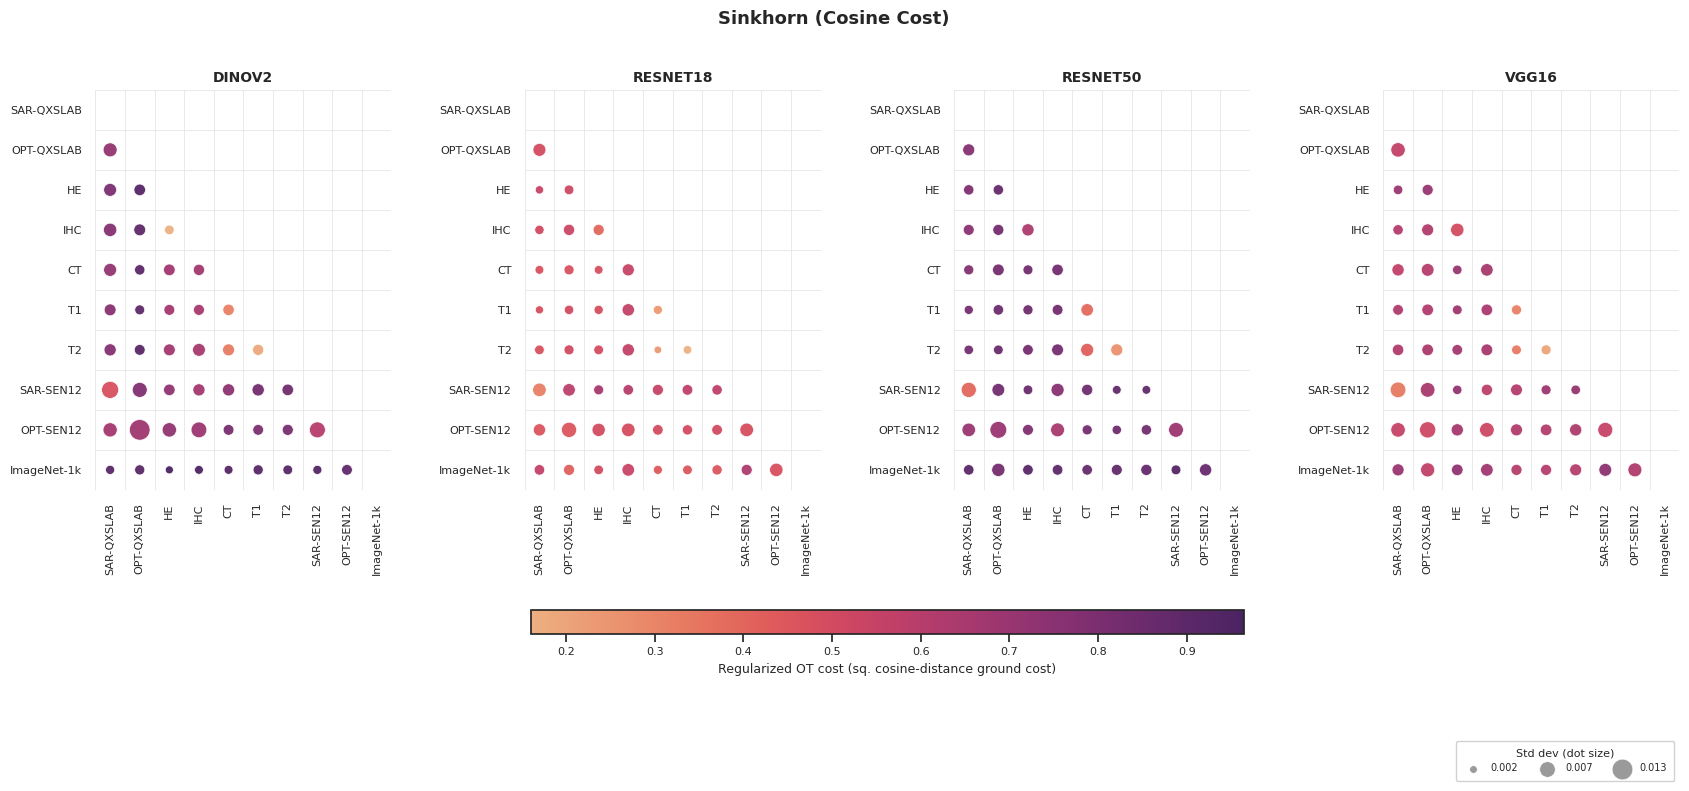

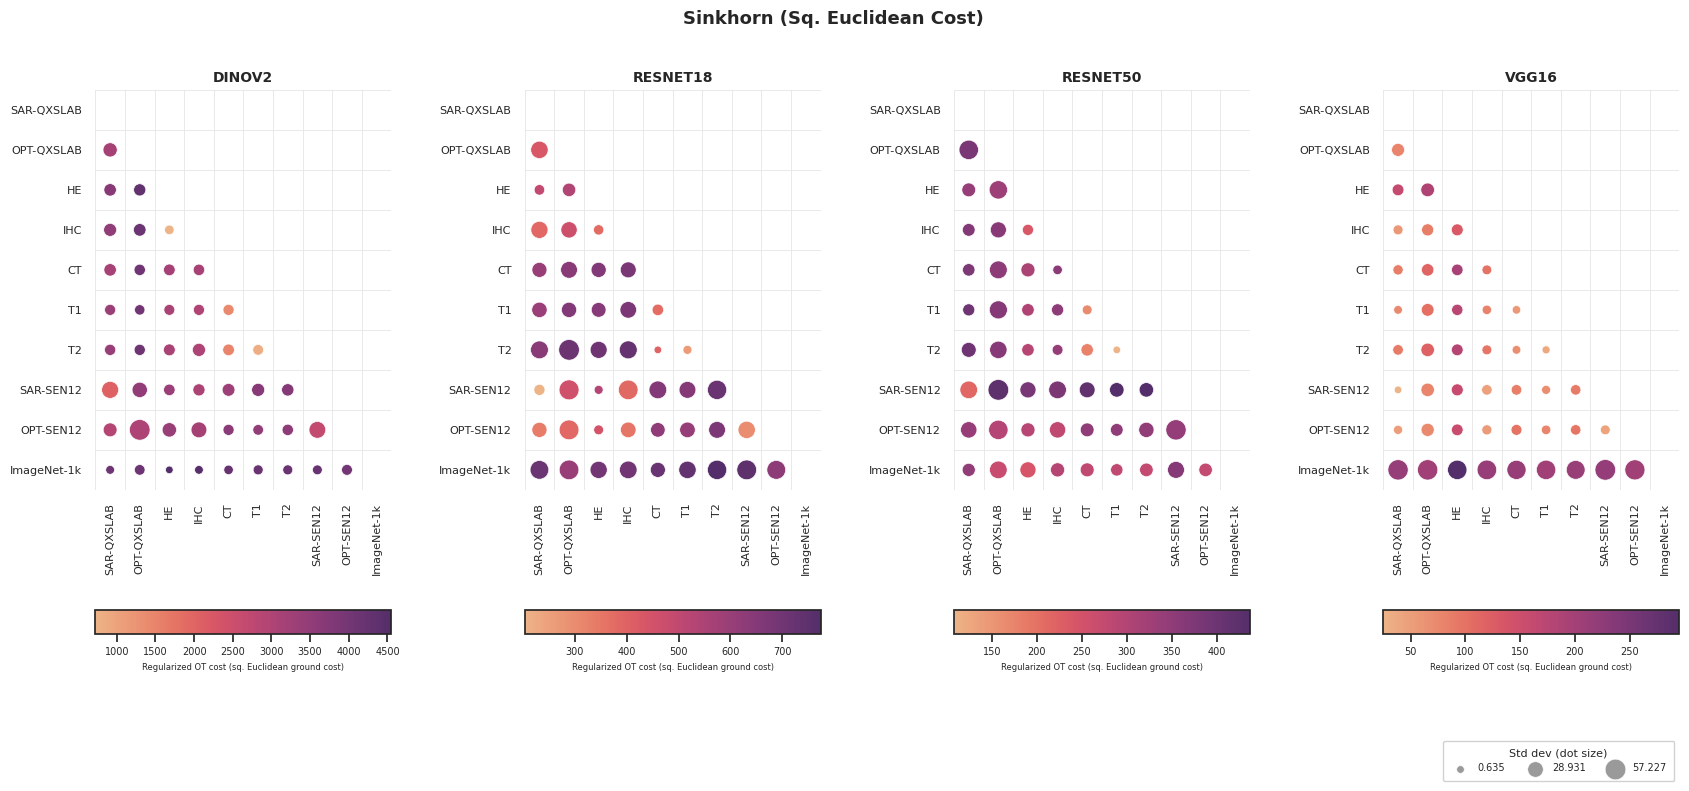

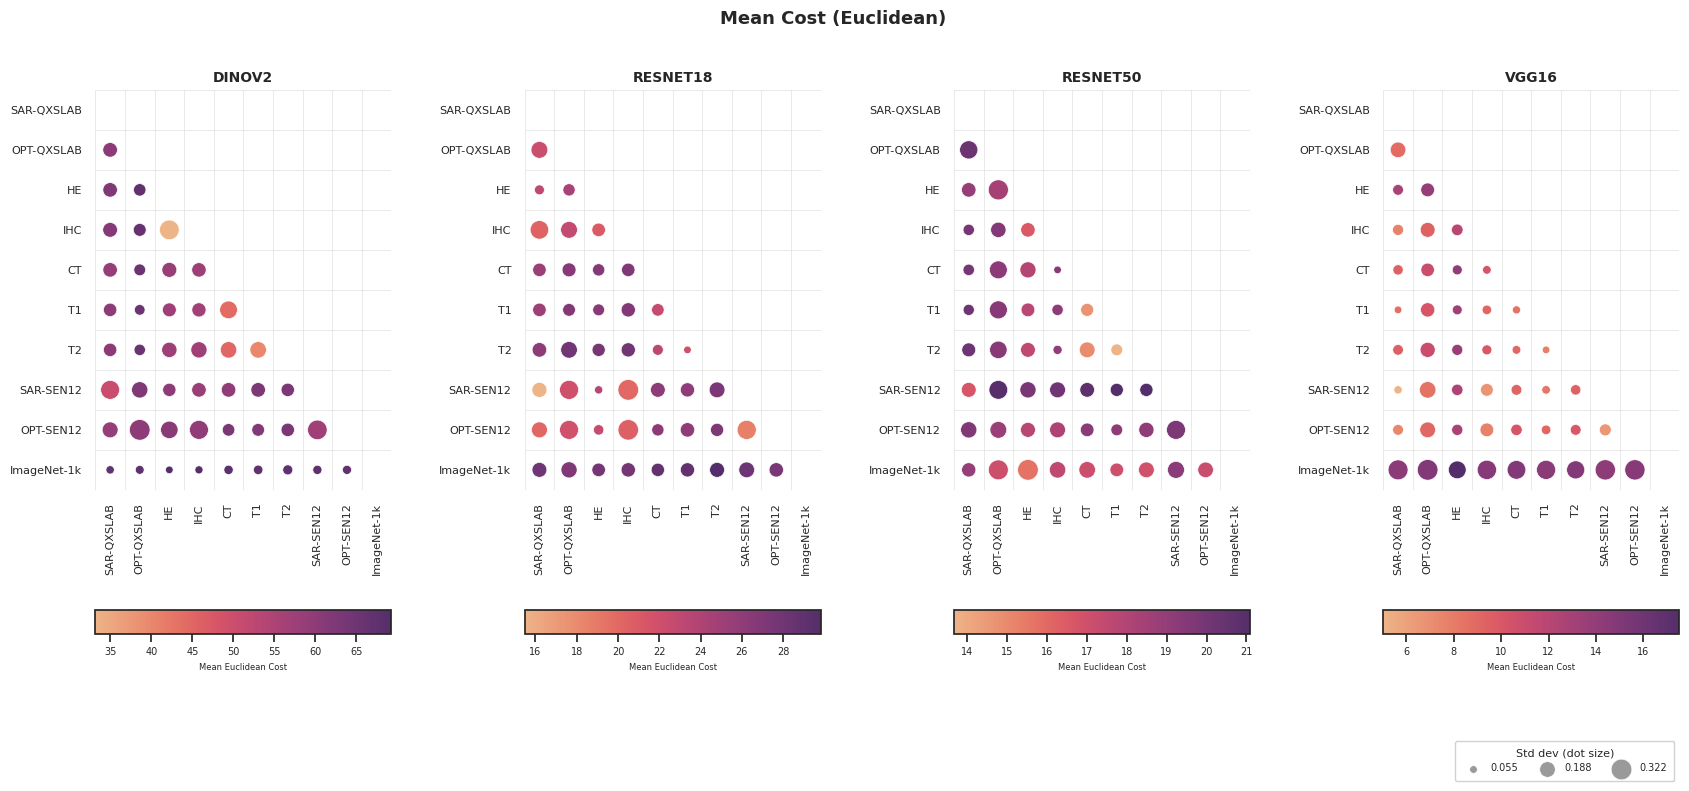

In [3]:
for metric in METRICS:
    plot_metric(metric)
    plt.show()